# Customer Review Intelligence  
## NLP, Emotion Analysis & LLM-Assisted Topic Modelling for Business Insight Extraction

**Project objective:** Convert large-scale customer review text into structured operational insight using topic modelling, emotion detection, and LLM-assisted thematic abstraction.

**Key techniques:** NLP preprocessing • BERTopic • Emotion Analysis • Topic Visualisation • LLM-based Topic Abstraction

# 1. Business Problem

Customer reviews contain valuable operational insight, but extracting consistent signals from large volumes of unstructured text is challenging.

The objective of this project is to design an NLP workflow that can:

- identify recurring complaint themes
- analyse emotional patterns behind customer feedback
- compare topic modelling approaches
- convert unstructured customer voice into actionable business insight

This project explores how modern NLP and LLM-assisted analysis can support decision-focused analytics from qualitative data.

# 2. Libraries & Environment Setup

This section imports the libraries required for:

- text preprocessing
- exploratory NLP analysis
- topic modelling
- emotion classification
- visualisation
- LLM-assisted insight generation

In [ ]:
import warnings
warnings.filterwarnings(
    "ignore",
    message="datetime.datetime.utcnow\\(\\) is deprecated",
    category=DeprecationWarning
)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

In [ ]:
!pip install bertopic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 14.8 MB/s eta 0:00:00


## Import required libraries

In [ ]:
# import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import re
import nltk

from nltk import FreqDist
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud
from bertopic import BERTopic

nltk.download('punkt')       # For sentence/token splitting
nltk.download("punkt_tab")
nltk.download('stopwords')   # For removing common stop words

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

# 3. Data Loading

The customer review dataset is loaded and prepared for analysis.

Initial inspection focuses on:

- dataset structure
- review volume
- location / branch segmentation


## Load the datasets

In [ ]:
# load the datasets
google_df = pd.read_excel("Google_12_months.xlsx")
trustpilot_df = pd.read_excel("Trustpilot_12_months.xlsx")

In [ ]:
google_df.head()


,Customer Name,SurveyID for external use (e.g. tech support),Club's Name,Social Media Source,Creation Date,Comment,Overall Score
0,**,ekkt2vyxtkwrrrfyzc5hz6rk,Leeds City Centre North,Google Reviews,2024-05-09 23:49:18,NaN,4
1,**,e9b62vyxtkwrrrfyzc5hz6rk,Cambridge Leisure Park,Google Reviews,2024-05-09 22:48:39,Too many students from two local colleges go h...,1
2,**,e2dkxvyxtkwrrrfyzc5hz6rk,London Holborn,Google Reviews,2024-05-09 22:08:14,"Best range of equipment, cheaper than regular ...",5
3,**,e3tfxvyxtkwrrrfyzc5hz6rk,Cheshunt Brookfield Shopping Park,Google Reviews,2024-05-09 21:58:07,"Good gym when it’s not busy, tend to get too b...",4
4,**,edkrxvyxtkwrrrfyzc5hz6rk,Bristol Union Gate,Google Reviews,2024-05-09 21:48:00,"(current member)\n\nGym is quite dirty, more o...",1


In [ ]:
google_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23250 entries, 0 to 23249
Data columns (total 7 columns):
 #   Column                                         Non-Null Count  Dtype         
---  ------                                         --------------  -----         
 0   Customer Name                                  23250 non-null  object        
 1   SurveyID for external use (e.g. tech support)  23250 non-null  object        
 2   Club's Name                                    23250 non-null  object        
 3   Social Media Source                            23250 non-null  object        
 4   Creation Date                                  23250 non-null  datetime64[ns]
 5   Comment                                        13898 non-null  object        
 6   Overall Score                                  23250 non-null  int64         
dtypes: datetime64[ns](1), int64(1), object(5)
memory usage: 1.2+ MB


In [ ]:
trustpilot_df.head()

,Review ID,Review Created (UTC),Review Consumer User ID,Review Title,Review Content,Review Stars,Source Of Review,Review Language,Domain URL,Webshop Name,Business Unit ID,Tags,Company Reply Date (UTC),Location Name,Location ID
0,663d40378de0a14c26c2f63c,2024-05-09 23:29:00,663d4036d5fa24c223106005,A very good environment,A very good environment,5,AFSv2,en,http://www.puregym.com,PureGym UK,508df4ea00006400051dd7b1,NaN,2024-05-10 08:12:00,Solihull Sears Retail Park,7b03ccad-4a9d-4a33-9377-ea5bba442dfc
1,663d3c101ccfcc36fb28eb8c,2024-05-09 23:11:00,5f5e3434d53200fa6ac57238,I love to be part of this gym,I love to be part of this gym. Superb value fo...,5,AFSv2,en,http://www.puregym.com,PureGym UK,508df4ea00006400051dd7b1,NaN,2024-05-10 08:13:00,Aylesbury,612d3f7e-18f9-492b-a36f-4a7b86fa5647
2,663d375859621080d08e6198,2024-05-09 22:51:00,57171ba90000ff000a18f905,Extremely busy,"Extremely busy, no fresh air.",1,AFSv2,en,http://www.puregym.com,PureGym UK,508df4ea00006400051dd7b1,NaN,NaT,Sutton Times Square,0b78c808-f671-482b-8687-83468b7b5bc1
3,663d4fa1f25670a3339ccf6d,2024-05-09 22:35:00,663d4fa0d5fa24251d1068e7,Great vibes,"Great vibes, fantastic gym",5,AFSv2,en,http://www.puregym.com,PureGym UK,508df4ea00006400051dd7b1,NaN,NaT,London Finchley,bc3a9a8c-defe-47b3-8ee6-f73a03b7447e
4,663d3251d8367b7b3c4ace64,2024-05-09 22:30:00,60c20598384d84001a4250de,Everything it needs to be,"Clean, well managed, classes are good.",5,AFSv2,en,http://www.puregym.com,PureGym UK,508df4ea00006400051dd7b1,NaN,2024-05-10 08:14:00,Crayford,9ce470b7-57df-4533-af2f-c539422fed14


In [ ]:
trustpilot_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16673 entries, 0 to 16672
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Review ID                 16673 non-null  object        
 1   Review Created (UTC)      16673 non-null  datetime64[ns]
 2   Review Consumer User ID   16673 non-null  object        
 3   Review Title              16673 non-null  object        
 4   Review Content            16673 non-null  object        
 5   Review Stars              16673 non-null  int64         
 6   Source Of Review          16673 non-null  object        
 7   Review Language           16673 non-null  object        
 8   Domain URL                16673 non-null  object        
 9   Webshop Name              16673 non-null  object        
 10  Business Unit ID          16673 non-null  object        
 11  Tags                      0 non-null      float64       
 12  Company Reply Date

## Remove missing reviews

In [ ]:
google_df = google_df.dropna(subset=["Comment"])
print("Google reviews after cleaning:", google_df.shape)

trustpilot_df = trustpilot_df.dropna(subset=["Review Content"])
print("Trustpilot reviews after cleaning:", trustpilot_df.shape)

print("\nNumber of Google reviews:", len(google_df))
print("Number of Trustpilot reviews:", len(trustpilot_df))

Google reviews after cleaning: (13898, 7)
Trustpilot reviews after cleaning: (16673, 15)

Number of Google reviews: 13898
Number of Trustpilot reviews: 16673


### Overview of the Datasets:
Google Dataset:
 - Initial Reviews: 23250
 - After cleaning: 13898

 Trustpilot Dataset:
  - Initial Reviews: 16673
 - After cleaning: 16673

## Initial Data Investigation

### Unique locations count

In [ ]:
google_locations = google_df["Club's Name"].nunique()
print("Unique Google locations:", google_locations)

trustpilot_locations = trustpilot_df["Location Name"].nunique()
print("Unique Trustpilot locations:", trustpilot_locations)

Unique Google locations: 512
Unique Trustpilot locations: 376


The Google Reviews dataset contains reviews from 512 unique gym locations, using Club's Name as the identifier.

The Trustpilot dataset contains reviews from 376 unique gym locations, using Location Name as the identifier.

### Common locations between datasets

In [ ]:
google_loc_set = set(google_df["Club's Name"].unique())
trustpilot_loc_set = set(trustpilot_df["Location Name"].unique())

common_locations = google_loc_set.intersection(trustpilot_loc_set)

print("Number of common locations:", len(common_locations))

Number of common locations: 310


A substantial overlap exists between Google and Trustpilot reviews, indicating that a large number of PureGym locations are reviewed across multiple platforms. This overlap allows for meaningful cross-platform comparison of customer feedback and strengthens the reliability of insights derived from combined analysis.

### Overview of the required data

In [ ]:
google_df[["Club's Name", "Comment", "Overall Score"]].head()

,Club's Name,Comment,Overall Score
1,Cambridge Leisure Park,Too many students from two local colleges go h...,1
2,London Holborn,"Best range of equipment, cheaper than regular ...",5
3,Cheshunt Brookfield Shopping Park,"Good gym when it’s not busy, tend to get too b...",4
4,Bristol Union Gate,"(current member)\n\nGym is quite dirty, more o...",1
5,"209 - Slagelse, Jernbanegade",Kom og betalte for en prøvetime i centret. Fik...,1


In [ ]:
trustpilot_df[["Location Name", "Review Content", "Review Stars"]].head()

,Location Name,Review Content,Review Stars
0,Solihull Sears Retail Park,A very good environment,5
1,Aylesbury,I love to be part of this gym. Superb value fo...,5
2,Sutton Times Square,"Extremely busy, no fresh air.",1
3,London Finchley,"Great vibes, fantastic gym",5
4,Crayford,"Clean, well managed, classes are good.",5


# 4. Text Cleaning & NLP Preprocessing

Customer review text is cleaned and normalised using preprocessing steps such as:

- lowercasing
- punctuation removal
- regex cleaning
- tokenisation
- stopword removal
- text normalisation

This creates a cleaner corpus for downstream modelling.

## Preprocessing of the data

In [ ]:
google_text = google_df["Comment"]
trustpilot_text = trustpilot_df["Review Content"]

In [ ]:
# Preprocessing function
stop_words = set(stopwords.words("english"))
domain_stopwords = {"puregym", "gym", "fitness", "pure"}

def base_clean(text):
    text = text.lower() # lowercase
    text = re.sub(r'\d+', '', text) # remove numbers
    text = re.sub(r'[^\w\s]', '', text) # remove punctuation
    text = re.sub(r'\s+', ' ', text).strip() # remove extra spaces
    text = " ".join(
        word for word in text.split()
        if word not in stop_words and word not in domain_stopwords
    )
    return text

def preprocess_for_frequency(text):
    if not isinstance(text, str) or text.strip() == "":
        return []

    cleaned = base_clean(text)
    return word_tokenize(cleaned)

def preprocess_for_bertopic(text):
    if not isinstance(text, str) or text.strip() == "":
        return ""

    return base_clean(text)


A shared preprocessing pipeline was created to standardise text, including lowercasing, removal of punctuation and numbers, and stopword elimination. Domain-specific stopwords (e.g., “gym”, “puregym”) were defined to avoid dominant but uninformative terms.

Tokenised text will be used for frequency-based analysis and word clouds, while cleaned full documents will be retained for BERTopic and LLM-based modelling to preserve contextual meaning.

In [ ]:
# Applying preprocessing on the reviews
google_df["tokens"] = google_df["Comment"].apply(preprocess_for_frequency)
trustpilot_df["tokens"] = trustpilot_df["Review Content"].apply(preprocess_for_frequency)

In [ ]:
google_df[["Comment", "tokens"]].head()


,Comment,tokens
1,Too many students from two local colleges go h...,"[many, students, two, local, colleges, go, lea..."
2,"Best range of equipment, cheaper than regular ...","[best, range, equipment, cheaper, regular, gym..."
3,"Good gym when it’s not busy, tend to get too b...","[good, busy, tend, get, busy, late, afternoon,..."
4,"(current member)\n\nGym is quite dirty, more o...","[current, member, quite, dirty, often, theres,..."
5,Kom og betalte for en prøvetime i centret. Fik...,"[kom, og, betalte, en, prøvetime, centret, fik..."


# 5. Exploratory Text Analysis

Before formal modelling, exploratory analysis is performed to understand:

- frequently occurring words
- dominant complaint vocabulary
- recurring linguistic patterns
- review length behaviour
- early thematic signals

Visual tools such as frequency plots and WordClouds help establish initial patterns.

## Frequency distribution of the words

In [ ]:

google_words = [word for tokens in google_df["tokens"] for word in tokens]
trustpilot_words = [word for tokens in trustpilot_df["tokens"] for word in tokens]

google_freq = FreqDist(google_words)
trustpilot_freq = FreqDist(trustpilot_words)


## Top 10 words

In [ ]:
print(google_freq.most_common(10))
print(trustpilot_freq.most_common(10))

[('equipment', 3608), ('great', 3555), ('good', 3451), ('staff', 2737), ('classes', 2311), ('clean', 1833), ('friendly', 1730), ('machines', 1704), ('always', 1691), ('really', 1525)]
[('equipment', 4396), ('good', 4082), ('great', 3789), ('staff', 3569), ('friendly', 2490), ('clean', 2489), ('classes', 2258), ('easy', 2187), ('machines', 1754), ('really', 1751)]


## Visualize top 10 words from each data set

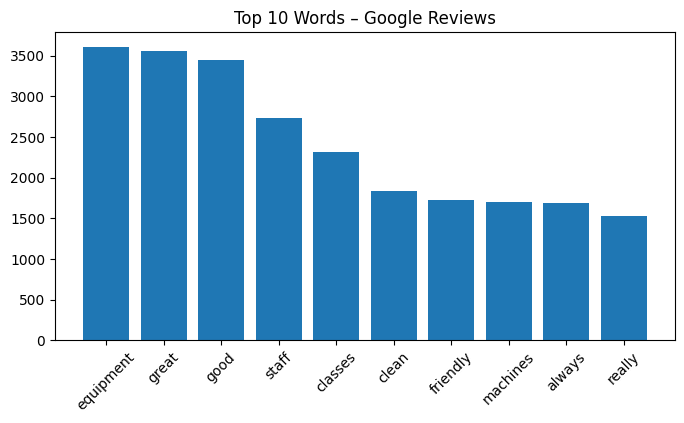

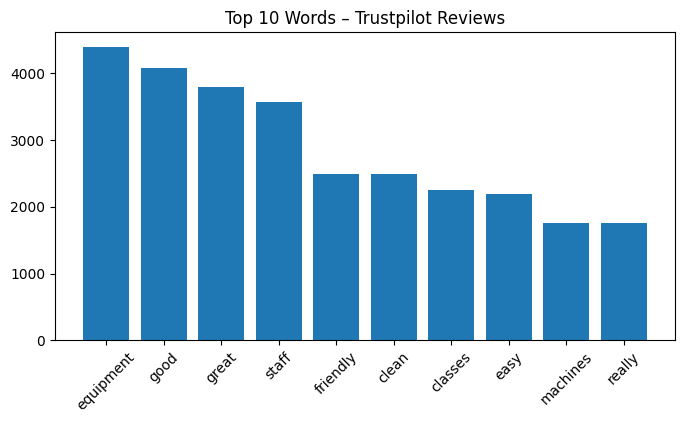

In [ ]:

def plot_top_words(freq_dist, title):
    words, counts = zip(*freq_dist.most_common(10))
    plt.figure(figsize=(8,4))
    plt.bar(words, counts)
    plt.title(title)
    plt.xticks(rotation=45)
    plt.show()

plot_top_words(google_freq, "Top 10 Words – Google Reviews")
plot_top_words(trustpilot_freq, "Top 10 Words – Trustpilot Reviews")


## Plot the word cloud

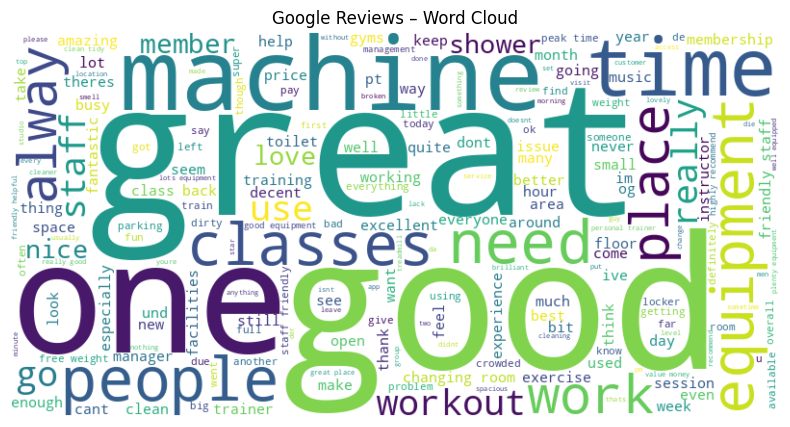

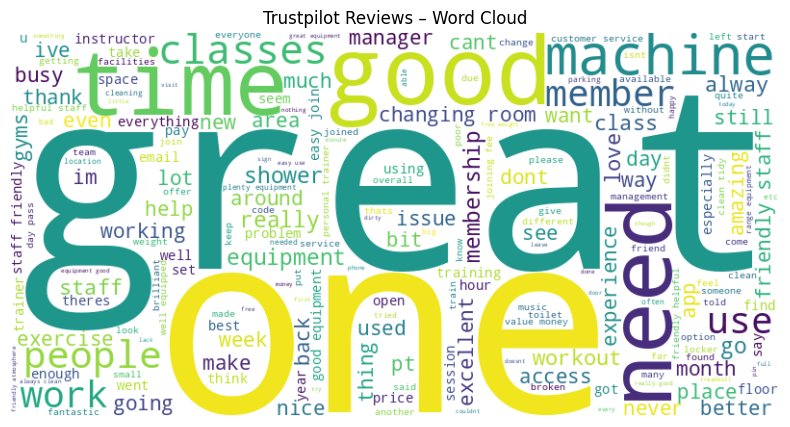

In [ ]:

def plot_wordcloud(words, title):
    text = " ".join(words)
    wc = WordCloud(
        width=800,
        height=400,
        background_color="white"
    ).generate(text)

    plt.figure(figsize=(10,5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title)
    plt.show()

plot_wordcloud(google_words, "Google Reviews – Word Cloud")
plot_wordcloud(trustpilot_words, "Trustpilot Reviews – Word Cloud")


Initial exploratory text analysis was conducted using word frequency distributions and a word cloud to gain a high-level understanding of commonly occurring terms with the reviews.

Here the most common words are great, one, good, time, machine, and people. This initial plots didn't reveal much about the customer dissatisfaction factors. Next step is to focus on the negative reviews to identify the common reasons for the dissatisfaction of the customers.

## Filter negative reviews and applying the preprocessing

In [ ]:
google_negative = google_df[google_df["Overall Score"] < 3]
trustpilot_negative = trustpilot_df[trustpilot_df["Review Stars"] < 3]

google_negative = google_negative.copy()
trustpilot_negative = trustpilot_negative.copy()

google_negative["tokens"] = google_negative["Comment"].apply(preprocess_for_frequency)
trustpilot_negative["tokens"] = trustpilot_negative["Review Content"].apply(preprocess_for_frequency)

Reviews were filtered to focus on negative reviews, defined as ratings below three stars on both platforms, allowing the analysis to concentrate on drivers of dissatisfaction rather than general feedback.

## Repeat the frequency distribution and the word cloud steps for negative reviews

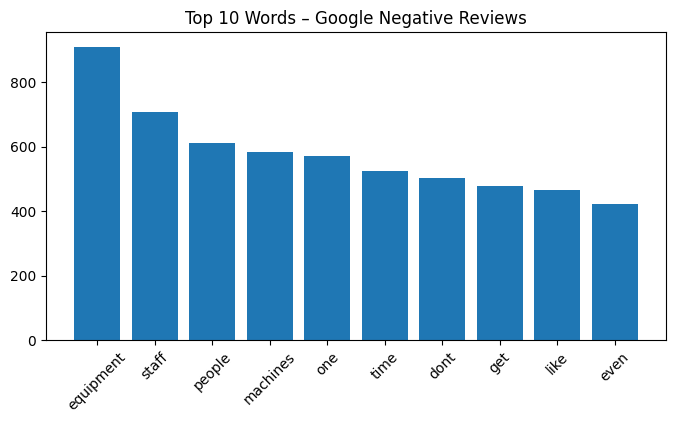

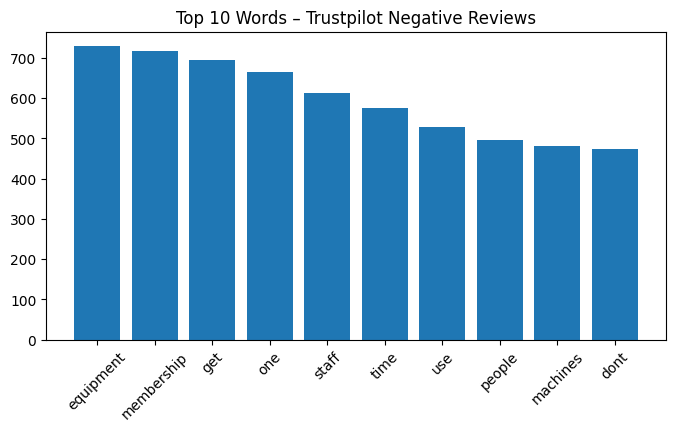

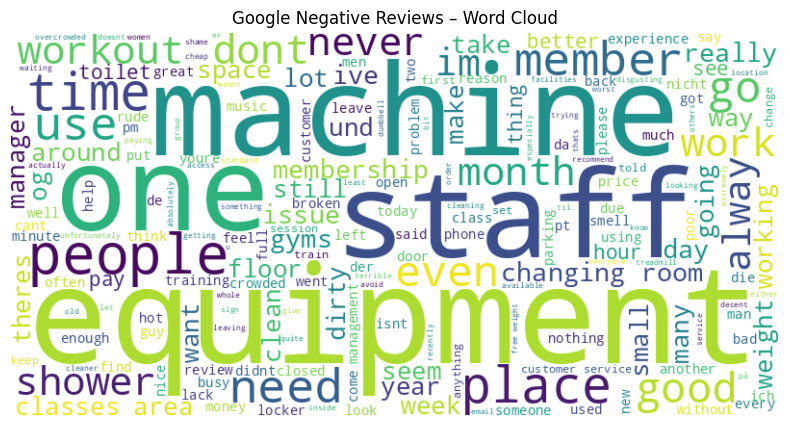

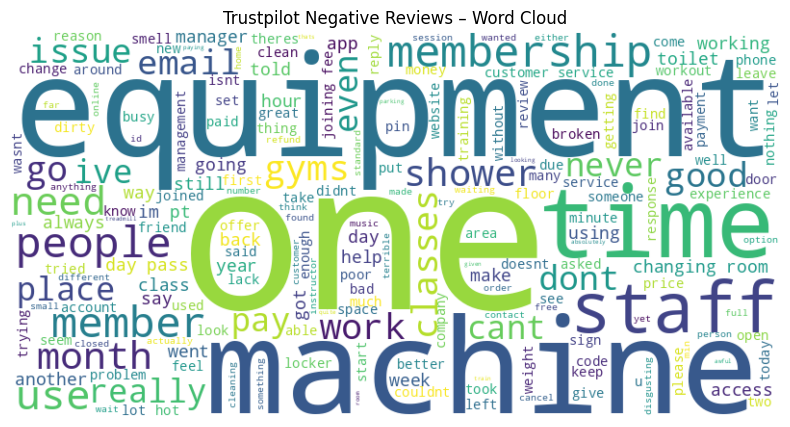

In [ ]:
google_neg_words = [word for tokens in google_negative["tokens"] for word in tokens]
trustpilot_neg_words = [word for tokens in trustpilot_negative["tokens"] for word in tokens]

google_neg_freq = FreqDist(google_neg_words)
trustpilot_neg_freq = FreqDist(trustpilot_neg_words)

plot_top_words(google_neg_freq, "Top 10 Words – Google Negative Reviews")
plot_top_words(trustpilot_neg_freq, "Top 10 Words – Trustpilot Negative Reviews")

plot_wordcloud(google_neg_words, "Google Negative Reviews – Word Cloud")
plot_wordcloud(trustpilot_neg_words, "Trustpilot Negative Reviews – Word Cloud")


The word frequency analysis and word clouds reveal recurring themes in customer feedback. While positive reviews tend to focus on general satisfaction and environment, negative reviews show stronger emphasis on operational issues such as cleanliness, equipment availability, staff behaviour, and membership. These patterns justify deeper topic modelling to uncover structured themes.

# 6. Topic Modelling with BERTopic

BERTopic is used as the primary topic modelling framework because it combines transformer embeddings with clustering-based topic discovery.

This enables:

- semantically coherent topic grouping
- flexible topic granularity
- improved interpretability compared with traditional topic models

The resulting topics are analysed for operational business meaning.

## Initial Topic Modelling

To get deeper understanding of the patterns/themes, negative reviews from the common locations are filtered and anlaysed further.

## Filter out the negative reviews from common locations

In [ ]:
# Get common locations
google_locations = set(google_df["Club's Name"].dropna().unique())
trustpilot_locations = set(trustpilot_df["Location Name"].dropna().unique())

common_locations = google_locations.intersection(trustpilot_locations)

print("Number of common locations: ", len(common_locations))


Number of common locations:  310


In [ ]:
# Google negative reviews (common locations)
google_neg_common = google_negative[
    google_negative["Club's Name"].isin(common_locations)
]

# Trustpilot negative reviews (common locations)
trustpilot_neg_common = trustpilot_negative[
    trustpilot_negative["Location Name"].isin(common_locations)
]
print("In the common locations")
print("Number of Negative Reviews in Google: ", len(google_neg_common))
print("Number of Negative reviews in Trustpilot: ", len(trustpilot_neg_common))


In the common locations
Number of Negative Reviews in Google:  2098
Number of Negative reviews in Trustpilot:  1852


In [ ]:
# Extract negative review text
google_texts = google_neg_common["Comment"].dropna().tolist()
trustpilot_texts = trustpilot_neg_common["Review Content"].dropna().tolist()

# Merge into one list
all_negative_reviews = google_texts + trustpilot_texts

print("Total number of Negative Reviews: ", len(all_negative_reviews))


Total number of Negative Reviews:  3950


## Preprocess the merged dataset

In [ ]:
clean_reviews = [
    preprocess_for_bertopic(review)
    for review in all_negative_reviews
    if preprocess_for_bertopic(review) != ""
]

## Apply BERTopic

In [ ]:
topic_model = BERTopic(
    language="english",
    calculate_probabilities=True,
    verbose=True
)

topics, probs = topic_model.fit_transform(clean_reviews)

2026-01-14 12:50:49,333 - BERTopic - Embedding - Transforming documents to embeddings.


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/124 [00:00<?, ?it/s]

2026-01-14 12:51:03,242 - BERTopic - Embedding - Completed ✓
2026-01-14 12:51:03,243 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-01-14 12:51:35,180 - BERTopic - Dimensionality - Completed ✓
2026-01-14 12:51:35,181 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-01-14 12:51:35,850 - BERTopic - Cluster - Completed ✓
2026-01-14 12:51:35,855 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-01-14 12:51:35,999 - BERTopic - Representation - Completed ✓


## List out the top topics

In [ ]:
topic_info = topic_model.get_topic_info()
topic_info.head(10)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,1765,-1_equipment_staff_machines_people,"[equipment, staff, machines, people, one, use,...",[join youre woman plenty gyms years never felt...
1,0,201,0_air_conditioning_hot_ac,"[air, conditioning, hot, ac, aircon, con, heat...",[air con seems big issue uncomfortable partake...
2,1,151,1_class_classes_instructors_cancelled,"[class, classes, instructors, cancelled, instr...",[forgot mobile staff let cycle class notified ...
3,2,117,2_parking_car_park_fine,"[parking, car, park, fine, free, fines, reg, t...","[free parking times, parking hours, get free p..."
4,3,102,3_music_loud_noise_headphones,"[music, loud, noise, headphones, hear, volume,...",[noise absolutely atrocious managersowners don...
5,4,101,4_toilets_dirty_changing_toilet,"[toilets, dirty, changing, toilet, rooms, smel...",[last months womens changing rooms without abs...
6,5,94,5_closed_open_christmas_opening,"[closed, open, christmas, opening, days, day, ...",[visited today pm closed notification closed n...
7,6,85,6_weights_dumbbells_plates_bench,"[weights, dumbbells, plates, bench, everywhere...",[overcrowded messy weights dumbbells clamps pl...
8,7,71,7_cold_showers_shower_water,"[cold, showers, shower, water, hot, temperatur...","[cold showers, showers cold, showers cold]"
9,8,67,8_membership_cancel_account_month,"[membership, cancel, account, month, suspended...",[last month suspended account reason called nu...


## List out the top words for top 2 topics

In [ ]:
top_topics = topic_info[topic_info.Topic != -1].head(2)

for topic in top_topics.Topic:
    print(f"\nTopic {topic}:")
    print(topic_model.get_topic(topic))


Topic 0:
[('air', np.float64(0.058875661289694084)), ('conditioning', np.float64(0.037528045562271926)), ('hot', np.float64(0.02990644773177388)), ('ac', np.float64(0.02913081338604152)), ('aircon', np.float64(0.026386909150120125)), ('con', np.float64(0.022456262449322507)), ('heat', np.float64(0.02094277332516486)), ('summer', np.float64(0.020767822514115204)), ('working', np.float64(0.018032722494800854)), ('warm', np.float64(0.01733551925524116))]

Topic 1:
[('class', np.float64(0.06700649568630969)), ('classes', np.float64(0.06292529139648077)), ('instructors', np.float64(0.023498314809949586)), ('cancelled', np.float64(0.020396116574047128)), ('instructor', np.float64(0.02037069889864921)), ('booked', np.float64(0.019353822702375185)), ('spin', np.float64(0.014447371647319516)), ('time', np.float64(0.013104793488678278)), ('late', np.float64(0.010815282539243609)), ('trainer', np.float64(0.010648732939056427))]


### Top words of the top 2 topics:

**Topic 1:** air, conditioning, hot, ac, aircon, con, summer, heat, working, temperature

**Topic 2:** class, classes, instructors, cancelled, instructor, booked, spin, time, late, trainer


# 7. Topic Visualisation & Interpretation

Multiple visual diagnostics are used to interpret discovered topics:

- Intertopic Distance Map
- Topic Frequency Bar Charts
- Topic Similarity Heatmaps

These help assess topic separation, overlap, and thematic coherence.

## Visualization of the topics

In [ ]:
# Intertopic Distance Map
topic_model.visualize_topics()

In [ ]:
# Tpoic Bar Chart
topic_model.visualize_barchart(top_n_topics=10)

In [ ]:
# Topic Similarity Heatmap
topic_model.visualize_heatmap()

**1. Air Conditioning and Temperature Issues**

Reviews in this topic highlight complaints about gyms being too hot and problems with air conditioning or ventilation, indicating discomfort during workouts and poor climate control.

**2. Lockers/Safety Issues**

This topic reflects customer frustration with the safety of their belongings, particularly with the access of lockers or the safety measures of the locker room.

**3. Cleanliness & Hygiene Concerns**

This topic highlights complaints about gym cleanliness, with customers mentioning dirty equipment or facilities and expressing dissatisfaction with overall hygiene standards.

**4. Fitness Classes & Scheduling Issues**

This topic relates to customer experiences with gym classes, including availability, scheduling, and overall satisfaction with how classes are organised or delivered.

**5. Parking Availability & Charges**

This topic highlights issues related to gym parking, including availability of parking spaces, free vs paid parking, and concerns about fines or parking enforcement.

**6. Toilets & Changing Room Hygiene**

This topic focuses on the cleanliness and maintenance of toilets and changing areas, including issues such as dirty facilities and missing essentials like soap.

**7. Music Volume & Noise Levels**

This topic highlights complaints about loud music and excessive noise in the gym, affecting members’ ability to focus, hear instructions, or work out comfortably.

**8. Opening Hours & Holiday Closures**

This topic reflects issues around gym opening and closing times, especially unexpected closures or reduced hours during holidays like Christmas, which inconvenience members.

**9. Gym Equipment & Overall Quality**

This topic focuses on members’ perceptions of gym equipment and facilities, generally reflecting opinions about equipment availability, condition, and overall gym quality.

**10. Value for Money & Membership Experience**

This topic reflects dissatisfaction around pricing, perceived lack of value, and negative overall experiences that lead members to regret joining or discourage repeat visits.

# 8. Location based analysis

As part of further investigation, now the focus is to analyse the top locations with highest number of negative reviews.

In [ ]:
print("Google negative reviews:", google_negative.shape)
google_negative.head()

Google negative reviews: (2785, 8)


,Customer Name,SurveyID for external use (e.g. tech support),Club's Name,Social Media Source,Creation Date,Comment,Overall Score,tokens
1,**,e9b62vyxtkwrrrfyzc5hz6rk,Cambridge Leisure Park,Google Reviews,2024-05-09 22:48:39,Too many students from two local colleges go h...,1,"[many, students, two, local, colleges, go, lea..."
4,**,edkrxvyxtkwrrrfyzc5hz6rk,Bristol Union Gate,Google Reviews,2024-05-09 21:48:00,"(current member)\n\nGym is quite dirty, more o...",1,"[current, member, quite, dirty, often, theres,..."
5,**,ewbyf88stkwrrrfyzc5hz6rk,"209 - Slagelse, Jernbanegade",Google Reviews,2024-05-09 21:36:17,Kom og betalte for en prøvetime i centret. Fik...,1,"[kom, og, betalte, en, prøvetime, centret, fik..."
7,**,erx6f88stkwrrrfyzc5hz6rk,New Barnet,Google Reviews,2024-05-09 20:16:04,This gym is way too hot to even workout in. Th...,2,"[way, hot, even, workout, windows, open, ac, b..."
19,**,em5fxz3stkwrrrfyzc5hz6rk,Manchester Cheetham Hill,Google Reviews,2024-05-09 17:03:50,No access for wc 😢. Empty and no assistance t...,2,"[access, wc, empty, assistance, gain, access, ..."


In [ ]:
print("Trustpilot negative reviews:", trustpilot_negative.shape)
trustpilot_negative.head()

Trustpilot negative reviews: (3543, 16)


,Review ID,Review Created (UTC),Review Consumer User ID,Review Title,Review Content,Review Stars,Source Of Review,Review Language,Domain URL,Webshop Name,Business Unit ID,Tags,Company Reply Date (UTC),Location Name,Location ID,tokens
2,663d375859621080d08e6198,2024-05-09 22:51:00,57171ba90000ff000a18f905,Extremely busy,"Extremely busy, no fresh air.",1,AFSv2,en,http://www.puregym.com,PureGym UK,508df4ea00006400051dd7b1,NaN,NaT,Sutton Times Square,0b78c808-f671-482b-8687-83468b7b5bc1,"[extremely, busy, fresh, air]"
19,663cf54657cc0d5b9e4c3cf6,2024-05-09 18:09:00,663cf54563436600872ebfaf,The men’s changing rooms smell bad,The men’s changing rooms smell bad. They need ...,2,AFSv2,en,http://www.puregym.com,PureGym UK,508df4ea00006400051dd7b1,NaN,NaT,Leeds City Centre South,2b4be59b-f0c3-4b19-a7e3-1ef2ce3719a9,"[mens, changing, rooms, smell, bad, need, deep..."
35,663cb2bb3dd3bfa5d9aa722d,2024-05-09 13:25:00,663cb2bac225531f31f22a41,All I wanted to do was set up another…,All I wanted to do was set up another debit ca...,1,AFSv2,en,http://www.puregym.com,PureGym UK,508df4ea00006400051dd7b1,NaN,NaT,NaN,NaN,"[wanted, set, another, debit, card, direct, de..."
36,663cb0d7d2ae954c99ee3bb1,2024-05-09 13:17:00,663cb0d6cb6e8d68d6aacb9c,What ever you do don’t downgrade your…,What ever you do don’t downgrade your membersh...,1,AFSv2,en,http://www.puregym.com,PureGym UK,508df4ea00006400051dd7b1,NaN,NaT,NaN,NaN,"[ever, dont, downgrade, membership, core, plus..."
38,663ca6eef65e849c2d5d78d9,2024-05-09 12:35:00,601e9e42862682001b88eb67,Awful Gyms,"Poor parking, not enough kit, unhelpful traine...",2,AFSv2,en,http://www.puregym.com,PureGym UK,508df4ea00006400051dd7b1,NaN,NaT,NaN,NaN,"[poor, parking, enough, kit, unhelpful, traine..."


## Top location of Google reviews

In [ ]:
google_top_locations = (
    google_negative
    .groupby("Club's Name")
    .size()
    .reset_index(name='Negative Review Count')
    .sort_values(by='Negative Review Count', ascending=False)
)

google_top_locations.head()

,Club's Name,Negative Review Count
319,London Stratford,59
330,London Woolwich,26
275,London Canary Wharf,26
285,London Enfield,25
321,London Swiss Cottage,24


## Top locations of Trustpilot reviews

In [ ]:
trustpilot_top_locations = (
    trustpilot_negative
    .groupby("Location Name")
    .size()
    .reset_index(name='Negative Review Count')
    .sort_values(by='Negative Review Count', ascending=False)
)

trustpilot_top_locations.head()

,Location Name,Negative Review Count
155,Leicester Walnut Street,50
0,345,45
186,London Enfield,23
219,London Stratford,22
58,Burnham,20


In [ ]:
# Take top 20 locations from each platform
google_top20 = set(google_top_locations.head(20)["Club's Name"])
trustpilot_top20 = set(trustpilot_top_locations.head(20)["Location Name"])

In [ ]:
common_locations = google_top20.intersection(trustpilot_top20)

print("Number of common top locations:", len(common_locations))
print("Common top locations of reviews:")
common_locations

Number of common top locations: 8
Common top locations of reviews:


{'Birmingham City Centre',
 'London Bermondsey',
 'London Enfield',
 'London Hayes',
 'London Seven Sisters',
 'London Stratford',
 'London Swiss Cottage',
 'New Barnet'}

In [ ]:
google_only = google_top20 - trustpilot_top20
print("Remaining Top location of Google reviews:")
google_only

Remaining Top location of Google reviews:


{'Bachenbülach',
 'Bradford Thornbury',
 'London Canary Wharf',
 'London Hoxton',
 'London Leytonstone',
 'London Palmers Green',
 'London Woolwich',
 'Manchester Exchange Quay',
 'Nottingham Colwick',
 'Peterborough Serpentine',
 'Wakefield',
 'Walsall Crown Wharf'}

In [ ]:
trustpilot_only = trustpilot_top20 - google_top20
print("Remaining Top location of Trustpilot reviews:")
trustpilot_only

Remaining Top location of Trustpilot reviews:


{345,
 'Birmingham Beaufort Park',
 'Burnham',
 'Leicester Walnut Street',
 'London Bromley',
 'London Finchley',
 'London Hammersmith Palais',
 'London Ilford',
 'Maidenhead',
 'Northwich',
 'Watford Waterfields',
 'York'}

**Observation on Top 20 Locations of both dataset:**

A programmatic comparison of the top 20 locations with the highest number of negative reviews reveals a significant overlap between Google and Trustpilot. This suggests that certain gym locations consistently attract negative feedback across platforms, indicating systemic issues rather than platform-specific sentiment. Additionally, a small number of locations appear uniquely in each platform, likely reflecting differences in user behaviour and review intent between Google and Trustpilot.

### Count of Google Reviews

In [ ]:
google_counts = (
    google_df
    .groupby("Club's Name")
    .size()
    .reset_index(name="Google_Review_Count")
)
google_counts.head()

,Club's Name,Google_Review_Count
0,"101 - Kbh. V., Gasværksvej",8
1,"105 - Kongensgade, Esbjerg",5
2,"106 - Frb., C. F. Richs Vej",5
3,"107 - Odense C., Slotscenter",4
4,"108 - Kbh NV., Emdrup Station",5


### Count of Trustpilot Reviews

In [ ]:
trustpilot_counts = (
    trustpilot_df
    .groupby("Location Name")
    .size()
    .reset_index(name="Trustpilot_Review_Count")
)
trustpilot_counts.head()

,Location Name,Trustpilot_Review_Count
0,345,174
1,398,42
2,Aberdeen Kittybrewster,44
3,Aberdeen Rubislaw,19
4,Aberdeen Shiprow,33


## Merge the Reviews

In [ ]:
location_review_counts = pd.merge(
    google_counts,
    trustpilot_counts,
    left_on="Club's Name",
    right_on="Location Name",
    how="outer"
)
location_review_counts.head()

,Club's Name,Google_Review_Count,Location Name,Trustpilot_Review_Count
0,NaN,NaN,345,174.0
1,NaN,NaN,398,42.0
2,"101 - Kbh. V., Gasværksvej",8.0,NaN,NaN
3,"105 - Kongensgade, Esbjerg",5.0,NaN,NaN
4,"106 - Frb., C. F. Richs Vej",5.0,NaN,NaN


Some locations were present in only one review platform. To account for this, an outer join was used when merging Google and Trustpilot datasets.

In [ ]:
# Clean missing values
location_review_counts[["Google_Review_Count", "Trustpilot_Review_Count"]] = (
    location_review_counts[["Google_Review_Count", "Trustpilot_Review_Count"]]
    .fillna(0)
    .astype(int)
)
location_review_counts.head()

,Club's Name,Google_Review_Count,Location Name,Trustpilot_Review_Count
0,NaN,0,345,174
1,NaN,0,398,42
2,"101 - Kbh. V., Gasværksvej",8,NaN,0
3,"105 - Kongensgade, Esbjerg",5,NaN,0
4,"106 - Frb., C. F. Richs Vej",5,NaN,0


In [ ]:
# Total Review Counts
location_review_counts["Total_Reviews"] = (
    location_review_counts["Google_Review_Count"] +
    location_review_counts["Trustpilot_Review_Count"]
)

#Single column - Location
location_review_counts["Location"] = (
    location_review_counts["Club's Name"]
    .combine_first(location_review_counts["Location Name"])
)

location_review_counts.head()

,Club's Name,Google_Review_Count,Location Name,Trustpilot_Review_Count,Total_Reviews,Location
0,NaN,0,345,174,174,345
1,NaN,0,398,42,42,398
2,"101 - Kbh. V., Gasværksvej",8,NaN,0,8,"101 - Kbh. V., Gasværksvej"
3,"105 - Kongensgade, Esbjerg",5,NaN,0,5,"105 - Kongensgade, Esbjerg"
4,"106 - Frb., C. F. Richs Vej",5,NaN,0,5,"106 - Frb., C. F. Richs Vej"


A unified location field was created by combining location names from both sources, ensuring all locations were retained for analysis while preserving accurate review counts.

In [ ]:
# Dropping unwanted columns(Club' Name & Location Name)
location_review_counts = location_review_counts.drop(
    columns=["Club's Name", "Location Name"]
)

# Rearranging the column order as expected
location_review_counts = location_review_counts[
    ["Location", "Google_Review_Count", "Trustpilot_Review_Count", "Total_Reviews"]
]

location_review_counts = location_review_counts.sort_values(by='Total_Reviews', ascending=False)
location_review_counts.head()

,Location,Google_Review_Count,Trustpilot_Review_Count,Total_Reviews
265,Elkridge,198,0,198
511,Springfield,194,0,194
392,London Park Royal,49,137,186
0,345,0,174,174
429,Manchester Market Street,134,30,164


After analysing the top locations separately for Google and Trustpilot reviews, the datasets were merged at the location level to identify gyms with the highest overall volume of negative feedback across platforms. This combined view enables a more holistic analysis of recurring issues and customer pain points.

In [ ]:
# Getting top 30 locations
top_30_locations = location_review_counts.head(30)
top_30_location_names = top_30_locations["Location"].tolist()

# Google neg comments of top 30 locations
google_top30_neg = google_negative[
    google_negative["Club's Name"].isin(top_30_location_names)
]
print("Google negative reviews (Top 30):", google_top30_neg.shape[0])

# Trustpilot neg comments of top 30 locations
trustpilot_top30_neg = trustpilot_negative[
    trustpilot_negative["Location Name"].isin(top_30_location_names)
]
print("Trustpilot negative reviews (Top 30):", trustpilot_top30_neg.shape[0])

Google negative reviews (Top 30): 329
Trustpilot negative reviews (Top 30): 354


In [ ]:
# Combine negative reviews text from Google and Trustpilot (Top 30 locations)
top30_reviews = (
    google_top30_neg["Comment"].dropna().tolist() +
    trustpilot_top30_neg["Review Content"].dropna().tolist()
)

print("Total number of reviews from top 30 locations: ", len(top30_reviews))


Total number of reviews from top 30 locations:  683


In [ ]:
# Apply preprocessing to the reviews
tokens_top30 = []

for review in top30_reviews:
    tokens_top30.extend(preprocess_for_frequency(review))

len(tokens_top30)

23038

In [ ]:
# Word frequency distribution

freq_dist_top30 = FreqDist(tokens_top30)
freq_dist_top30.most_common(10)

[('equipment', 204),
 ('people', 186),
 ('staff', 164),
 ('get', 163),
 ('time', 154),
 ('one', 152),
 ('machines', 140),
 ('use', 132),
 ('like', 129),
 ('dont', 128)]

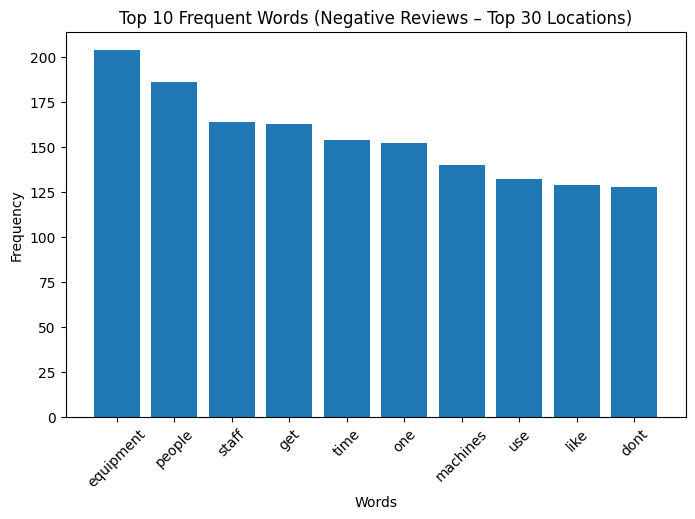

In [ ]:
# Plot top 10 words with barchart
top_words = freq_dist_top30.most_common(10)
words, counts = zip(*top_words)

plt.figure(figsize=(8,5))
plt.bar(words, counts)
plt.title("Top 10 Frequent Words (Negative Reviews – Top 30 Locations)")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

**Observation on Top 30 Locations – Word Frequency**

The most frequent words highlight equipment availability and usage issues, with terms like equipment, machines, and use appearing prominently. Words such as people and time suggest overcrowding and long wait times, especially during peak hours. The presence of staff indicates that customer support or staff responsiveness may also contribute to dissatisfaction at these high-complaint locations. Overall, negative feedback in these locations points to operational capacity challenges rather than isolated service issues.

In [ ]:
# Standardise column names
google_top30_neg = google_top30_neg.rename(
    columns={"Club's Name": "Location", "Comment": "Review"}
)

trustpilot_top30_neg = trustpilot_top30_neg.rename(
    columns={"Location Name": "Location", "Review Content": "Review"}
)

# Keep only required columns
google_top30_neg = google_top30_neg[["Location", "Review"]]
trustpilot_top30_neg = trustpilot_top30_neg[["Location", "Review"]]

# Combine into one dataframe
top30_reviews = pd.concat(
    [google_top30_neg, trustpilot_top30_neg],
    ignore_index=True
)


In [ ]:
# Apply preprocessing to each review
top30_reviews["clean_tokens"] = top30_reviews["Review"].apply(preprocess_for_frequency)

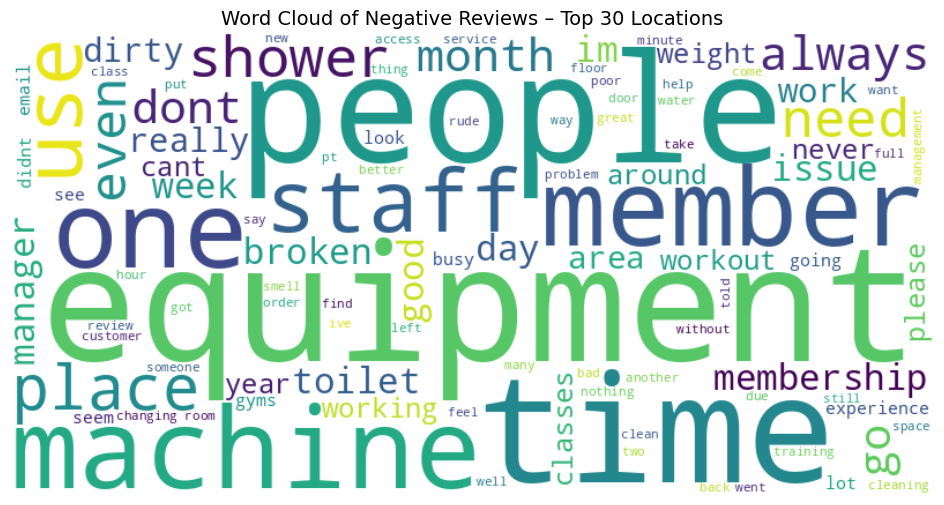

In [ ]:
# Generate word cloud for reviews of top 30 locations
# text_top30 = " ".join(top30_reviews["Review"].dropna())
text_top30 = " ".join(word for tokens in top30_reviews["clean_tokens"] for word in tokens)

# Create the word cloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    max_words=100
).generate(text_top30)

# Plot the word cloud
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Negative Reviews – Top 30 Locations", fontsize=14)
plt.show()



**Comparison Insight:**

The initial word clouds for Google and Trustpilot negative reviews show similar high-frequency terms such as equipment, staff, time, and membership, indicating consistent dissatisfaction patterns across platforms. However, these terms remain broad and do not clearly identify specific operational issues.

When the analysis is focused on negative reviews from the top 30 locations, more actionable terms emerge, including broken machines, dirty showers, toilets, and equipment availability. This shift highlights that dissatisfaction is largely driven by recurring, location-level operational issues, motivating the use of topic modelling and LLM-based analysis for deeper thematic understanding.

## BERTopic on top 30 locations

In [ ]:
# Convert reviews to list
top30_docs = top30_reviews["Review"].dropna().tolist()

clean30_reviews = [
    preprocess_for_bertopic(review)
    for review in top30_docs
    if preprocess_for_bertopic(review) != ""
]
# Run BERTopic
topic_model_top30 = BERTopic(
    language="english",
    calculate_probabilities=True,
    verbose=True
)

topics_top30, probs_top30 = topic_model_top30.fit_transform(clean30_reviews)

2026-01-14 12:53:30,685 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/22 [00:00<?, ?it/s]

2026-01-14 12:53:34,976 - BERTopic - Embedding - Completed ✓
2026-01-14 12:53:34,978 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-01-14 12:53:37,371 - BERTopic - Dimensionality - Completed ✓
2026-01-14 12:53:37,372 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-01-14 12:53:37,420 - BERTopic - Cluster - Completed ✓
2026-01-14 12:53:37,424 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-01-14 12:53:37,463 - BERTopic - Representation - Completed ✓


In [ ]:
# View top topics
topic_info_top30 = topic_model_top30.get_topic_info()
print(topic_info_top30.head(10))

   Topic  Count                               Name  \
0     -1    199       -1_equipment_time_people_get   
1      0    110             0_email_didnt_pin_code   
2      1     77  1_cleaning_toilets_dirty_changing   
3      2     57        2_rude_manager_member_staff   
4      3     49       3_showers_shower_cold_please   
5      4     48   4_machines_machine_broken_months   
6      5     32   5_weights_dumbbells_bench_people   
7      6     24      6_air_aircon_conditioning_hot   
8      7     22   7_locker_another_people_downhill   
9      8     14            8_parking_park_car_free   

                                      Representation  \
0  [equipment, time, people, get, one, like, dont...   
1  [email, didnt, pin, code, pass, day, month, fe...   
2  [cleaning, toilets, dirty, changing, equipment...   
3  [rude, manager, member, staff, like, im, voice...   
4  [showers, shower, cold, please, mould, water, ...   
5  [machines, machine, broken, months, order, equ...   
6  [weights, 

In [ ]:
# Display top words for top 5 topics
for topic_id in topic_info_top30["Topic"].head(5):
    print(f"\nTopic {topic_id}:")
    print(topic_model_top30.get_topic(topic_id))


Topic -1:
[('equipment', np.float64(0.025786053620757633)), ('time', np.float64(0.020586799617700744)), ('people', np.float64(0.02036856222511107)), ('get', np.float64(0.018233370119426964)), ('one', np.float64(0.017731730234895986)), ('like', np.float64(0.017423754379547435)), ('dont', np.float64(0.017122325864143226)), ('use', np.float64(0.01659081169796347)), ('water', np.float64(0.016423337352675694)), ('staff', np.float64(0.016276329468376923))]

Topic 0:
[('email', np.float64(0.03700315932627763)), ('didnt', np.float64(0.030414670981646026)), ('pin', np.float64(0.0292773704066987)), ('code', np.float64(0.0292773704066987)), ('pass', np.float64(0.027539144226820352)), ('day', np.float64(0.02725743820878829)), ('month', np.float64(0.02719114622407532)), ('fee', np.float64(0.02673151211046403)), ('membership', np.float64(0.026002128447090236)), ('service', np.float64(0.02550907888783215))]

Topic 1:
[('cleaning', np.float64(0.06475487229594971)), ('toilets', np.float64(0.0544962082

## Visualization on top 30 locations

In [ ]:
# Intertopic distane map
topic_model_top30.visualize_topics()

In [ ]:
# Topic bar chart
topic_model_top30.visualize_barchart(top_n_topics=10)

In [ ]:
# Similarity heatmap
topic_model_top30.visualize_heatmap()

**Comparision Insight on BERTopic: (Negative Reviews of all vs top 30 locations)**

By applying BERTopic on negative reviews of top 30 locations, some additional insigths were discovered more clearly. Here, the dominant words within each topic clearly highlight distinct themes such as equipment issues, access problems, cleanliness concerns, poor customer service, and environmental comfort, enabling meaningful interpretation.

# 9. Emotion Analysis

Beyond sentiment polarity, transformer-based emotion classification is used to identify richer emotional patterns such as:

- anger
- frustration
- disappointment
- satisfaction
- excitement

This provides deeper behavioural context behind customer feedback themes.# 5. Conducting Emotion Analysis

## Load the Emotion Classification Model

In [ ]:
from transformers import pipeline

emotion_classifier = pipeline(
    "text-classification",
    model="bhadresh-savani/bert-base-uncased-emotion",
    return_all_scores=True,
    truncation=True,
    max_length=512
)

config.json:   0%|          | 0.00/935 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/285 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Device set to use cuda:0


In [ ]:
example_text1 = "The gym is overcrowded and the equipment is always broken."
emotion_scores = emotion_classifier(example_text1)
print("Example 1:", example_text1)
emotion_scores

Example 1: The gym is overcrowded and the equipment is always broken.


[[{'label': 'sadness', 'score': 0.941360354423523},
  {'label': 'joy', 'score': 0.00047313328832387924},
  {'label': 'love', 'score': 0.0005777964252047241},
  {'label': 'anger', 'score': 0.006091007497161627},
  {'label': 'fear', 'score': 0.05064002051949501},
  {'label': 'surprise', 'score': 0.0008577295229770243}]]

In [ ]:
example_text2 = "The staff were rude and the gym was extremely dirty."

emotion_scores = emotion_classifier(example_text2)
print("Example 2:", example_text2)
emotion_scores

Example 2: The staff were rude and the gym was extremely dirty.


[[{'label': 'sadness', 'score': 0.000828366435598582},
  {'label': 'joy', 'score': 0.00019232698832638562},
  {'label': 'love', 'score': 0.0004246023017913103},
  {'label': 'anger', 'score': 0.9974579215049744},
  {'label': 'fear', 'score': 0.0007760992739349604},
  {'label': 'surprise', 'score': 0.00032070750603452325}]]

## Apply Emotion Analysis to negative reviews

In [ ]:
# Sample to data
google_sample = google_negative.sample(n=1200, random_state=42)
trustpilot_sample = trustpilot_negative.sample(n=1200, random_state=42)

In [ ]:
# Funtion to get Top Emotion

def get_top_emotion(text):
    scores = emotion_classifier(str(text))[0]
    return max(scores, key=lambda x: x['score'])['label']

In [ ]:
# Apply to Google negative reviews
google_sample['emotion'] = google_sample['Comment'].apply(get_top_emotion)

# Apply to Trustpilot negative reviews
trustpilot_sample['emotion'] = trustpilot_sample['Review Content'].apply(get_top_emotion)

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


In [ ]:
# Save emotion analysis results to avoid recomputation
google_sample.to_csv("google_negative_with_emotion.csv", index=False)
trustpilot_sample.to_csv("trustpilot_negative_with_emotion.csv", index=False)

In [ ]:
# Load cached emotion results if available
google_sample = pd.read_csv("google_negative_with_emotion.csv")
trustpilot_sample = pd.read_csv("trustpilot_negative_with_emotion.csv")

In [ ]:
google_sample['emotion'].value_counts().head()

,count
emotion,
anger,513
sadness,309
joy,267
fear,80
love,20


In [ ]:
trustpilot_sample['emotion'].value_counts().head()

,count
emotion,
anger,560
joy,285
sadness,251
fear,64
love,25


## Visualization of Emotion Distribution

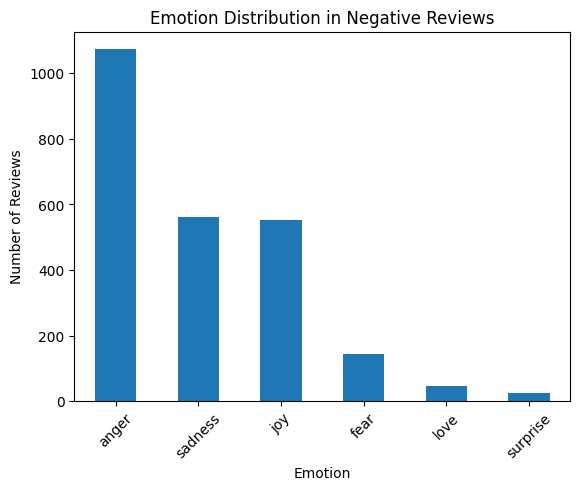

In [ ]:

emotion_counts = (
    pd.concat([
        google_sample['emotion'],
        trustpilot_sample['emotion']
    ])
    .value_counts()
)

emotion_counts.plot(kind='bar')
plt.title("Emotion Distribution in Negative Reviews")
plt.xlabel("Emotion")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)
plt.show()


## Filter Angry Reviews

In [ ]:
angry_reviews = pd.concat([
    google_sample[google_sample['emotion'] == 'anger']['Comment'],
    trustpilot_sample[trustpilot_sample['emotion'] == 'anger']['Review Content']
]).dropna().tolist()

## Run BERTopic on Angry Reviews

In [ ]:
clean_angry_reviews = [
    preprocess_for_bertopic(review)
    for review in angry_reviews
    if preprocess_for_bertopic(review) != ""
]

In [ ]:
angry_topic_model = BERTopic(
    language="english",
    verbose=True
)
angry_topics, angry_probs = angry_topic_model.fit_transform(clean_angry_reviews)

2026-01-14 12:54:10,791 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/34 [00:00<?, ?it/s]

2026-01-14 12:54:14,983 - BERTopic - Embedding - Completed ✓
2026-01-14 12:54:14,984 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-01-14 12:54:18,166 - BERTopic - Dimensionality - Completed ✓
2026-01-14 12:54:18,167 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-01-14 12:54:18,199 - BERTopic - Cluster - Completed ✓
2026-01-14 12:54:18,203 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-01-14 12:54:18,241 - BERTopic - Representation - Completed ✓


## Visualization of Angry Reviews

In [ ]:
angry_topic_model.visualize_topics()


In [ ]:
angry_topic_model.visualize_barchart()

**Observation:**

The emotion-oriented keyword analysis produced a small number of broad clusters rather than clearly differentiated emotional themes. The extracted groups largely reflect surface-level complaint contexts (e.g., staff, equipment, time), location-specific operational issues (parking, fines, fees), and noise or language artefacts (e.g., og, er, der, ikke), rather than distinct emotional states.

# 10. LLM-Assisted Topic Abstraction

Local LLM experimentation is used to improve topic naming, summarisation, and business interpretation.

The objective is to:

- produce clearer topic labels
- abstract recurring complaint clusters
- synthesise business-facing recommendations
- improve interpretability beyond raw topic keywords

Initial experiments with FLAN-T5 primarily produced generic summaries rather than well-separated or interpretable topics. Falcon-7B-Instruct could not be reliably executed due to GPU memory limitations in the Google Colab environment, and although Phi4-mini ran locally, it was difficult to integrate and reproduce consistently within the notebook-based workflow.

Consequently, Qwen2.5-3B-Instruct, an instruction-tuned model available via Hugging Face, was selected. The model executed efficiently on Colab with GPU acceleration and demonstrated reliable adherence to structured prompts, making it suitable for topic abstraction and insight generation from customer reviews.

## Load the Model

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
import torch

model_id = "Qwen/Qwen2.5-3B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    device_map="auto"
)

generator = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer
)


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Device set to use cuda:0


## Define the prompt

In [ ]:
def extract_topics(review):
    prompt = f"""
You are analysing negative customer reviews of gym facilities.

Identify distinct, concise complaint themes that reflect recurring operational or service issues mentioned in the reviews.

Rules:
- Each theme must be 2–4 words
- Do not repeat similar themes
- Do not include placeholders, generic labels, or unrelated topics
- Themes must be relevant to gym operations, facilities, staff, or membership experience

Return the output as a plain list of themes, one per line.

Customer review:
{review}

"""
    output = generator(
        prompt,
        max_new_tokens=200,
        do_sample=False
    )
    return output[0]["generated_text"]


## Run the model with the subset of data

In [ ]:
subset_reviews = clean_angry_reviews[:50]

topic_outputs = []
for r in subset_reviews:
    topic_outputs.append(extract_topics(r))


The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


## Create comprehensive topic list

In [ ]:
import re

all_topics = []

for text in topic_outputs:
    topics = re.findall(r"\d+\.\s*(.+)", text)
    all_topics.extend(topics)

len(all_topics)


287

### View the extracted topics

In [ ]:
all_topics[:50]

['Water leaks',
 'Week maintenance',
 'Ridiculous water',
 'Maintenance issues',
 'Unreliable plumbing',
 'Water overflow',
 'Plumbing problems',
 'Inadequate repairs',
 'Water damage',
 'Faulty plumbing',
 'Leaky pipes',
 'Poor maintenance',
 'Overflowing water',
 'Broken pipes',
 'Inefficient repairs',
 'Water leakage',
 'Plumbing failure',
 'Water leak',
 'Faulty plumbing system',
 'Pipe burst',
 'Water pipe issues',
 'Leaking pipes',
 'Water supply problems',
 'Plumbing malfunction',
 'Water leak detection',
 'Water pipe leak',
 'Pipe burst issue',
 'Water pipe failure',
 'Water supply fault',
 'Pipe burst problem',
 'Water pipe leak detection',
 '**Equipment management**: The review mentions "good amount equipment" but then talks about "always packed time go people never put weights back."',
 '**Weight storage**: This is directly related to the issue with weights not being returned.',
 '**Attendance impact**: The review indicates that "thousand people attend everyday" and suggests

The initial set of extracted topics are more similar along with few other topics

In [ ]:
all_topics[50:100]

['Inaccurate guidance',
 'Misleading referral',
 'Inadequate support',
 'Lack of assistance',
 'Unclear instructions',
 'Confusing directions',
 'Faulty equipment',
 'Broken machines',
 'Defective gear',
 'Malfunctioning apparatus',
 'Inoperable器械',
 'Non-functional equipment',
 'Faulty fitness equipment',
 'Inoperative gym equipment',
 'Broken workout machines',
 'Defective gym equipment',
 'Inoperable gym apparatus',
 'Non',
 'Exploitative charges',
 'Cancellation difficulty',
 'Corporate grimey',
 'Independent vibe',
 'Exploitative charges',
 'Cancellation difficulty',
 'Corporate grimey',
 'Independent vibe',
 'Equipment substandard',
 'Staff unfriendly',
 'Hot water issues',
 'Personal trainer neglect',
 'Instructors rudeness',
 'Exercise guidance errors',
 'Poor phone etiquette',
 'Greeting indifference',
 'Membership cancellation',
 'Facility cleanliness',
 'Training injuries',
 'Young staff attitude',
 'Lack of professionalism',
 'Unfriendly reception',
 'Shower hygiene',
 'Con

To check the quality of the extracted topics, another set of output was listed. The above list shows various distinct topics from the negative reviews, which are good to proceed with further steps of extracting actionable insights.

## Run the BERTopic on the LLM extracted topics

In [ ]:
topic_model_llm = BERTopic(
    language="english",
    verbose=True
)
topics_llm, probs_llm = topic_model_llm.fit_transform(all_topics)

2026-01-14 13:01:49,885 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/9 [00:00<?, ?it/s]

2026-01-14 13:01:53,170 - BERTopic - Embedding - Completed ✓
2026-01-14 13:01:53,171 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-01-14 13:01:53,708 - BERTopic - Dimensionality - Completed ✓
2026-01-14 13:01:53,709 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-01-14 13:01:53,750 - BERTopic - Cluster - Completed ✓
2026-01-14 13:01:53,753 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-01-14 13:01:53,765 - BERTopic - Representation - Completed ✓


In [ ]:
# Visualize the LLM topics
topic_model_llm.visualize_topics()

In [ ]:
topic_model_llm.visualize_barchart()

**Interpretation of LLM-based BERTopic Results:**

The LLM-based BERTopic results reinforce and refine the dissatisfaction themes identified earlier through word clouds and standard BERTopic analysis. Previously observed high-frequency terms such as staff, equipment, machine, cleanliness, time, and membership now emerge as well-defined, semantically coherent topics, improving interpretability.

Specifically, customer dissatisfaction clusters around:

- Service quality and staff behaviour (Topic 1), aligning with earlier prominence of staff and people in negative reviews.

- Equipment availability, maintenance, and training (Topics 2 and 4), consistent with recurring mentions of machines, broken equipment, and repairs.

- Facility infrastructure issues such as plumbing and water leaks (Topic 3), expanding on earlier maintenance-related complaints.

- Cleanliness and hygiene concerns (Topic 5), which mirrors frequent references to dirty, smell, and toilet in the word cloud analysis.

- Membership management and cancellation problems (Topic 6), corroborating earlier complaints around membership, lockouts, and access.

- Parking and navigation confusion (Topic 7), reflecting location-specific friction previously observed.

- Billing and security-related issues (Topic 8), highlighting concerns around direct debit charges and perceived exploitative practices.

Overall, the LLM-enhanced BERTopic approach transforms surface-level keyword patterns into actionable thematic categories, validating earlier findings while offering clearer structure for downstream insight generation and recommendations.

## Genrate insights from the extracted topics

In [ ]:
def generate_insights(topic_list):
    # text_blob = "\n".join(topic_list)

    prompt = f"""
You are a business consultant specialising in customer experience for fitness centres.

You are given a cleaned list of recurring customer complaint themes extracted from negative gym reviews.

Your task:
- Group related issues
- Identify the most critical customer pain points
- Provide clear, practical, business-focused recommendations

Rules:
- Do NOT repeat the input topics verbatim
- Do NOT include analysis of individual reviews
- Focus only on gym operations, facilities, staff, and member experience
- Keep recommendations concise and actionable

Output format:
Return 5 numbered actionable recommendations, where each recommendation includes:
- The underlying problem
- A concrete action the gym can take
- A brief expected benefit

Complaint Themes:
{topic_list}
"""
    output = generator(
        prompt,
        max_new_tokens=400,
        do_sample=False
    )
    return output[0]["generated_text"]


In [ ]:
final_insights = generate_insights(all_topics)
print(final_insights)


You are a business consultant specialising in customer experience for fitness centres.

You are given a cleaned list of recurring customer complaint themes extracted from negative gym reviews.

Your task:
- Group related issues
- Identify the most critical customer pain points
- Provide clear, practical, business-focused recommendations

Rules:
- Do NOT repeat the input topics verbatim
- Do NOT include analysis of individual reviews
- Focus only on gym operations, facilities, staff, and member experience
- Keep recommendations concise and actionable

Output format:
Return 5 numbered actionable recommendations, where each recommendation includes:
- The underlying problem
- A concrete action the gym can take
- A brief expected benefit

Complaint Themes:
['Water leaks', 'Week maintenance', 'Ridiculous water', 'Maintenance issues', 'Unreliable plumbing', 'Water overflow', 'Plumbing problems', 'Inadequate repairs', 'Water damage', 'Faulty plumbing', 'Leaky pipes', 'Poor maintenance', 'Over

The actionable insights effectively convert recurring complaint themes into targeted operational recommendations, particularly around staff conduct, cleanliness, training, and equipment maintenance. This step bridges the gap between topic discovery and practical business impact.

# 11. Topic Modelling with Gensim (LDA Baseline)

As a statistical baseline, **Latent Dirichlet Allocation (LDA)** was applied using Gensim to uncover recurring themes in customer dissatisfaction reviews.

The workflow involved:

- creating a dictionary from cleaned tokenised review text  
- constructing a bag-of-words corpus  
- training an LDA topic model to identify latent topics  
- visualising topic relationships using **pyLDAvis**  
- analysing topic prevalence through a **Top 10 Topics bar chart**

This baseline helped identify dominant complaint themes such as operational issues, cleanliness, overcrowding, customer service, and access-related concerns, while also providing a benchmark for comparison with embedding-based topic modelling approaches like **BERTopic**.

In [ ]:
!pip install gensim pyLDAvis matplotlib nltk --quiet

import gensim
from gensim import corpora
from gensim.models import LdaModel
import pyLDAvis
import pyLDAvis.gensim_models

## Preprocess the reviews

In [ ]:
# Combine Google & Trustpilot negative reviews
# Assume negative_reviews is a list containing all negative review texts
negative_reviews_combined = all_negative_reviews


# Preprocess all reviews
tokenized_reviews = [preprocess_for_frequency(r) for r in negative_reviews_combined]


## Create Dictionary and Corpus

In [ ]:
# Create a dictionary representation of the documents
dictionary = corpora.Dictionary(tokenized_reviews)

# Filter extremes to remove very rare and very common words
dictionary.filter_extremes(no_below=5, no_above=0.5)

# Create a Bag-of-Words corpus
corpus = [dictionary.doc2bow(text) for text in tokenized_reviews]


## Build LDA Model

In [ ]:
num_topics = 10
lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=num_topics,
    random_state=42,
    passes=10,
    alpha='auto',
    per_word_topics=True
)


## Explore Topics

In [ ]:
# Print the top 10 words for each topic
for i, topic in lda_model.show_topics(num_topics=num_topics, num_words=10, formatted=False):
    print(f"Topic {i}: {[word for word, prob in topic]}")


Topic 0: ['air', 'equipment', 'like', 'hot', 'conditioning', 'working', 'good', 'con', 'really', 'work']
Topic 1: ['parking', 'closed', 'email', 'membership', 'get', 'hours', 'car', 'day', 'time', 'staff']
Topic 2: ['class', 'classes', 'dont', 'membership', 'customer', 'help', 'manager', 'service', 'pt', 'cancelled']
Topic 3: ['equipment', 'people', 'get', 'time', 'staff', 'one', 'machines', 'busy', 'machine', 'even']
Topic 4: ['day', 'showers', 'changing', 'pass', 'shower', 'cold', 'room', 'rooms', 'equipment', 'work']
Topic 5: ['water', 'showers', 'dont', 'months', 'cold', 'like', 'one', 'machine', 'shower', 'hot']
Topic 6: ['weights', 'membership', 'get', 'would', 'pin', 'experience', 'back', 'people', 'one', 'staff']
Topic 7: ['dirty', 'cleaning', 'changing', 'toilets', 'rooms', 'always', 'toilet', 'clean', 'broken', 'equipment']
Topic 8: ['machines', 'equipment', 'weights', 'area', 'people', 'space', 'one', 'use', 'small', 'music']
Topic 9: ['staff', 'equipment', 'member', 'manage

The LDA model surfaced ten dominant themes related to facility maintenance, overcrowding, cleanliness, parking, membership management, and staff interactions. While some overlap exists across topics, the results highlight consistent operational pain points, particularly around infrastructure reliability, service quality, and capacity management. These findings informed subsequent topic refinement using BERTopic and LLM-assisted analysis.

## Visualize topics with pyLDAvis

In [ ]:
pyLDAvis.enable_notebook()
lda_vis = pyLDAvis.gensim_models.prepare(lda_model, corpus, dictionary)
lda_vis


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
8     -0.078638  0.055490       1        1  18.112588
9      0.023014  0.070374       2        1  13.148539
5     -0.045530  0.009605       3        1  10.062283
3     -0.023462  0.051371       4        1   9.717815
2      0.177224  0.005035       5        1   9.584866
0     -0.075428  0.077627       6        1   9.292451
7     -0.195578 -0.028067       7        1   9.270790
1      0.148546 -0.066486       8        1   8.197061
6      0.110522  0.043795       9        1   7.986863
4     -0.040669 -0.218743      10        1   4.626745, topic_info=           Term        Freq       Total Category  logprob  loglift
191         air  363.000000  363.000000  Default  30.0000  30.0000
3      changing  460.000000  460.000000  Default  29.0000  29.0000
729     showers  408.000000  408.000000  Default  28.0000  28.0000
337       water  378.000000  378.000000  Default  27.0000  27.0000
879       class  334.000000  334.000000  Default  26.0000  26.0000
..          ...         ...         ...      ...      ...      ...
340         bad   27.271863  237.437688  Topic10  -5.2566   0.9093
187      really   29.610797  444.839276  Topic10  -5.1744   0.3637
244        time   31.103833  797.229336  Topic10  -5.1252  -0.1705
16   membership   27.497232  570.305312  Topic10  -5.2484   0.0412
53         even   27.457592  553.655857  Topic10  -5.2499   0.0694

[791 rows x 6 columns], token_table=      Topic      Freq   Term
term                        
401       1  0.213079   able
401       2  0.065563   able
401       3  0.049172   able
401       4  0.172102   able
401       5  0.057367   able
...     ...       ...    ...
26        9  0.007486  years
26       10  0.026201  years
1668      1  0.118411  youve
1668      3  0.710464  youve
1668      9  0.157881  youve

[2191 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[9, 10, 6, 4, 3, 1, 8, 2, 7, 5])

## Bar Chart

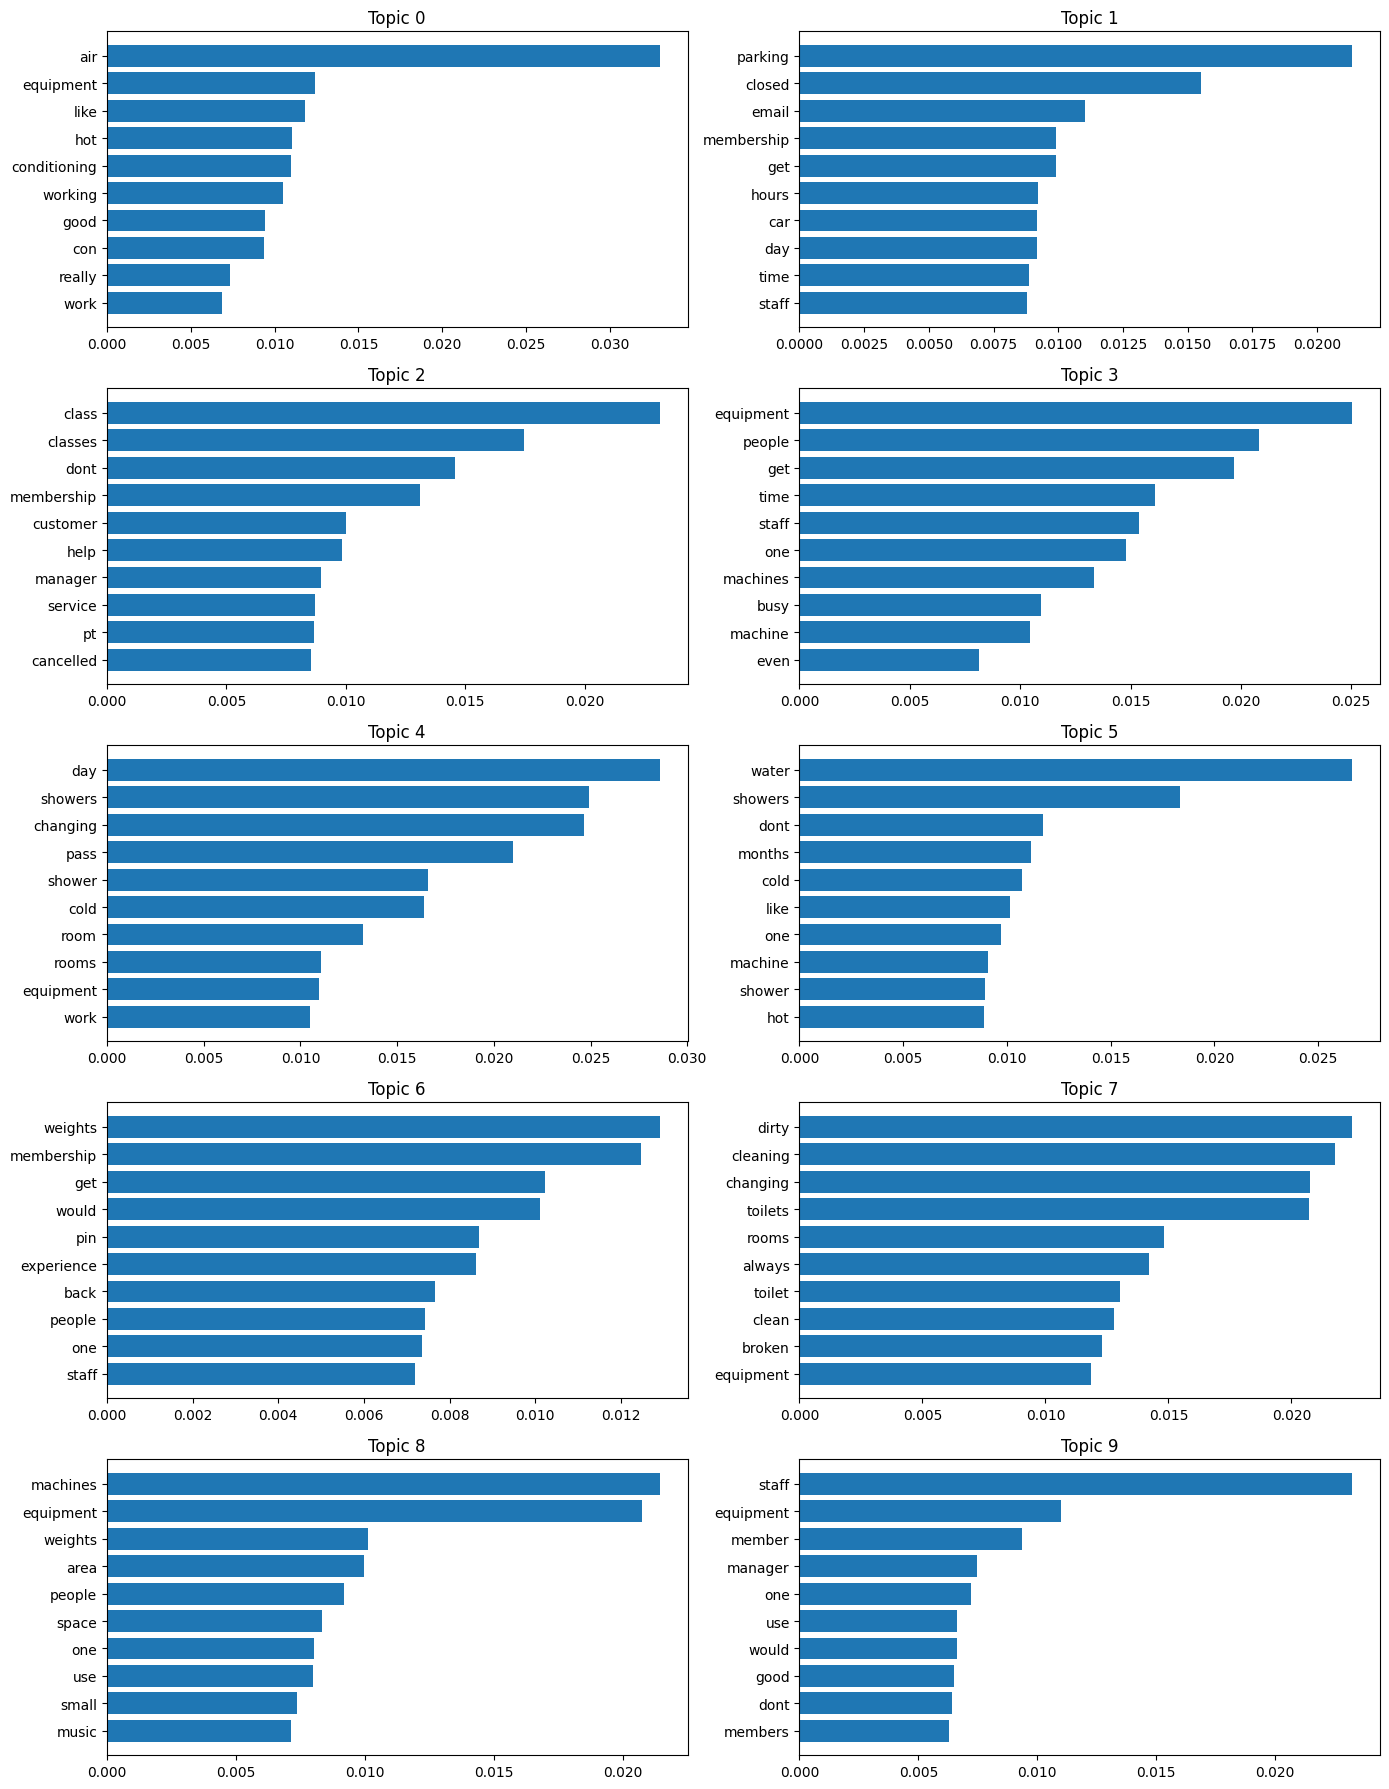

In [ ]:
fig, axes = plt.subplots(5, 2, figsize=(14, 18))
axes = axes.flatten()

for topic_id, ax in enumerate(axes[:10]):
    words_probs = lda_model.show_topic(topic_id, topn=10)
    words = [w for w, p in words_probs]
    probs = [p for w, p in words_probs]

    ax.barh(words, probs)
    ax.invert_yaxis()
    ax.set_title(f"Topic {topic_id}")

plt.tight_layout()
plt.show()

Topic Observations (10 topics):

Topic 0: Issues with air conditioning and hot classes; people mention class timings and working conditions in the gym.

Topic 1: Complaints about cleanliness and maintenance; dirty rooms, broken machines, and locker problems are common.

Topic 2: Focus on toilets, changing rooms, and staff; cleanliness and staff behavior are noted.

Topic 3: Problems with membership, staff interaction, and access; people mention delays or difficulties getting help.

Topic 4: Equipment usage and availability; some machines are broken or insufficient, leading to overcrowding issues.

Topic 5: Issues with showers and water temperature; some mention showers not working or cold water.

Topic 6: Staff and management complaints; rude staff, manager behavior, and issues with personal trainers (PTs).

Topic 7: Customer service and staff interactions; complaints about responses, manager communication, and service quality.

Topic 8: Gym equipment and space constraints; overcrowding, busy machines, and music/noise complaints.

Topic 9: Access, parking, and membership logistics; problems with passes, pins, emails, or parking availability.

General Insights:

Most topics align with common complaints highlighted in BERTopic and emotion analysis (e.g., cleanliness, staff behavior, equipment issues, showers, access problems).

Some topics are overlapping, which is typical in LDA, but it still confirms the main themes across locations.

The output is consistent with other topic modelling approaches, validating the insights. LDA also highlights operational issues (showers, AC, parking) alongside staff/customer service problems.

# 12. Key Findings

Key findings from the analysis include:

- **Operational issues dominate dissatisfaction** — customer complaints were largely driven by recurring systemic issues such as equipment faults, cleanliness, overcrowding, access problems, customer service friction, and membership-related concerns.

- **Traditional NLP provides useful baselines but limited semantic clarity** — word frequency analysis and LDA topic modelling identified broad complaint themes, but topic overlap reduced interpretability.

- **BERTopic improved thematic coherence** — embedding-based topic modelling produced clearer, more distinct, and business-relevant themes compared with LDA.

- **Cross-method consistency strengthened confidence** — recurring themes appeared consistently across frequency analysis, LDA, and BERTopic, increasing confidence that findings reflected genuine operational patterns.

- **LLM-assisted interpretation improved actionability** — Qwen-generated abstraction translated technical topic clusters into clearer business recommendations around maintenance, communication, service quality, and operational transparency.

- **Customer dissatisfaction appears systemic rather than isolated** — findings indicate recurring operational process weaknesses rather than one-off customer complaints.

# 13. Conclusion

This project demonstrates how a structured NLP workflow can convert large-scale unstructured customer feedback into robust, decision-ready business insight.

By combining:

- exploratory text analysis  
- statistical topic modelling (LDA)  
- embedding-based semantic clustering (BERTopic)  
- emotion-aware interpretation  
- LLM-assisted topic abstraction  

the analysis moved beyond simple sentiment reporting toward deeper operational intelligence.

The strongest insight from the project was that **customer dissatisfaction is largely driven by recurring operational friction points rather than isolated incidents**, highlighting clear opportunities for service improvement.

Overall, this work shows how combining traditional NLP techniques with modern LLM-assisted analysis creates a scalable and effective framework for extracting actionable insight from customer voice data.